# 6. The error is a bias, and the bias is geometry

Notebooks 1 and 5 both end in the same place from different directions. Notebook 1: no
covariance a robot can learn from its own drive makes the belief honest, because the
camera's error is not centred on zero. Notebook 5: the deployed way of producing
$\mathbf{R}$ for a candidate pose cannot represent the covariance's shape, its endpoint
is wider than the measured noise, and for any useful trust it returns an unregistered
constant.

Both are statements about what $\mathbf{R}$ *cannot* do. This notebook is about what to
do instead, and the claim is narrow enough to defend:

> **The spatial dependence belongs in the observation function, not in the noise
> covariance.** The camera's error is about 90% a repeatable, pose-dependent
> displacement, that displacement is predictable from the robot's own geometry with
> **zero fitted parameters and no ground truth**, and what is left over is small enough
> for a covariance to describe honestly.

It then asks the question a committee will ask — *what if the camera is not calibrated
as well as you think?* — and shows that a calibration error is the same kind of object,
handled by the same machinery, and **not** fixed by inflating $\mathbf{R}$.

### Evidence scope

The four recorded single-camera drives in the AWS warehouse. Ground truth scores and
never steers. The calibration section is a **controlled ablation, clearly labelled**:
the recorded pixels are untouched real data and only our belief about where the camera
is moves — which is exactly what a miscalibration is, and the one thing these captures
cannot contain on their own, because the projection is parsed from the same world file
Gazebo renders from.

In [1]:
import notebook_data as nd
import notebook_model as nm
import notebook_views as nv
import numpy as np

nv.style()
LEAD = "camera_A"
ANALYSIS = "aws_aisle_east_north"
DRIVES = [ANALYSIS, "aws_apron_west_to_east", "aws_aisle_west_north", "aws_mid_cross_east"]

capture = nd.load_capture(ANALYSIS)
models = nd.camera_models()
truth_table = nd.load_truth(ANALYSIS)
seq = nm.Sequence(capture, truth_table, window=nd.route_window(ANALYSIS))

## How much of the error is even noise?

Split the residual $\mathbf{y}_k - \mathbf{x}^{\text{true}}_k$ into the part that
repeats and the part that does not.

In [2]:
split = nm.bias_and_noise(seq, LEAD, models, truth_table)

nv.report_bias_and_noise(split, LEAD)

  camera A, 276 readings

  the whole error, typically            8.77 cm
  of which repeats every reading      (-0.67, -8.62) cm
  and the scatter about it              0.83 cm

  so 91% of it is a LEAN, not noise —
  and after predicting that lean from geometry:   0.81 cm
  (91% of the error removed, zero fitted parameters)


Nine tenths of it repeats. A covariance describes the other tenth, and it was being
asked to carry all of it — which is why every arm in notebook 1 failed, including the
one handed the true covariance measured on the very drive it was filtering.

## Predicting the part that repeats

The displacement is not mysterious. The pipeline reports where the **bottom-centre
pixel of the detector's box** back-projects to; the truth reports `base_footprint`, the
floor point midway between the wheels. Two different points, by definition. So predict
the first from the second:

1. take the robot's actual surface from its URDF meshes;
2. put it at the pose in question and project every vertex through the camera model;
3. take the bounding box's bottom-centre pixel — the same convention the detector uses;
4. back-project that pixel to the floor.

The gap between that and the pose you started from is the predicted displacement. There
is **nothing fitted**: no regression, no lookup table, no constant tuned on residuals.
It needs the robot's shape, the camera's pose and the robot's heading, and all three are
available at run time.

In [3]:
transfer = nm.prediction_transfer(DRIVES, LEAD, models)

nv.report_prediction_transfer(transfer)

  drive                       n    no fix   truth yaw   ODOM yaw   yaw = 0
  aisle east north          276    8.77 cm      0.81 cm     0.89 cm    2.48 cm
  apron west to east        272   10.26 cm      1.65 cm     1.68 cm    1.65 cm
  aisle west north          224    9.66 cm      1.12 cm     1.14 cm    3.72 cm
  mid cross east             94    7.81 cm      3.10 cm     3.19 cm    3.10 cm
  ----------------------------------------------------------------------
  POOLED                    866    9.44 cm      1.42 cm     1.41 cm    2.55 cm

  Odometry heading does as well as the true heading and uses NO ground truth,
  removing 85% of the error with zero fitted parameters.
  The last column is the control: assuming the robot always points the same way
  scores 2.55 cm against 1.41 cm, so the pose-dependence is doing real work.


Read the last two columns together. **Odometry heading does as well as the true
heading** — the robot does not need to know where it is pointing to better than its own
dead reckoning already does. And the control fails: assuming the robot always points the
same way is markedly worse, so the prediction is genuinely using the pose and is not a
constant offset in disguise.

It transfers across four routes that differ in range, bearing and occlusion. The worst
is the cross-aisle drive, and that is the one where the robot spends much of its time
partly behind a rack — the predictor assumes it can see the whole silhouette, so it
degrades exactly where you would expect it to.

## What that does to the belief — and what a calibration error does

Four treatments of the same error, under three states of calibration. The first column
is the camera as modelled; the other two have the camera model deliberately wrong in
pitch, with the recorded pixels untouched.

In [4]:
table = nm.calibration_arms(seq, models, LEAD, degrees=(0.0, 0.1, 0.5))

nv.report_calibration_arms(table)

                                                   correct           0.1 deg off           0.5 deg off
  arm                                  too sure       RMSE   too sure       RMSE   too sure       RMSE
  R = the true scatter                     8.9x    8.80 cm      12.3x   10.71 cm       8.9x   18.96 cm
  R inflated to cover it all               3.3x    9.43 cm       3.7x   11.38 cm       4.0x   18.85 cm
  observation function corrected           1.1x    3.02 cm       2.0x    3.72 cm       4.6x   11.30 cm
  offset carried in the state              0.1x    1.32 cm       0.2x    2.47 cm       0.6x    7.58 cm

  Read the RMSE columns across: inflating R never improves accuracy in any
  column. It buys an admission of being wrong, and nothing else. Modelling the
  bias improves accuracy AND honesty, and degrades gracefully as calibration
  drifts, because a calibration error is another pose-dependent bias.


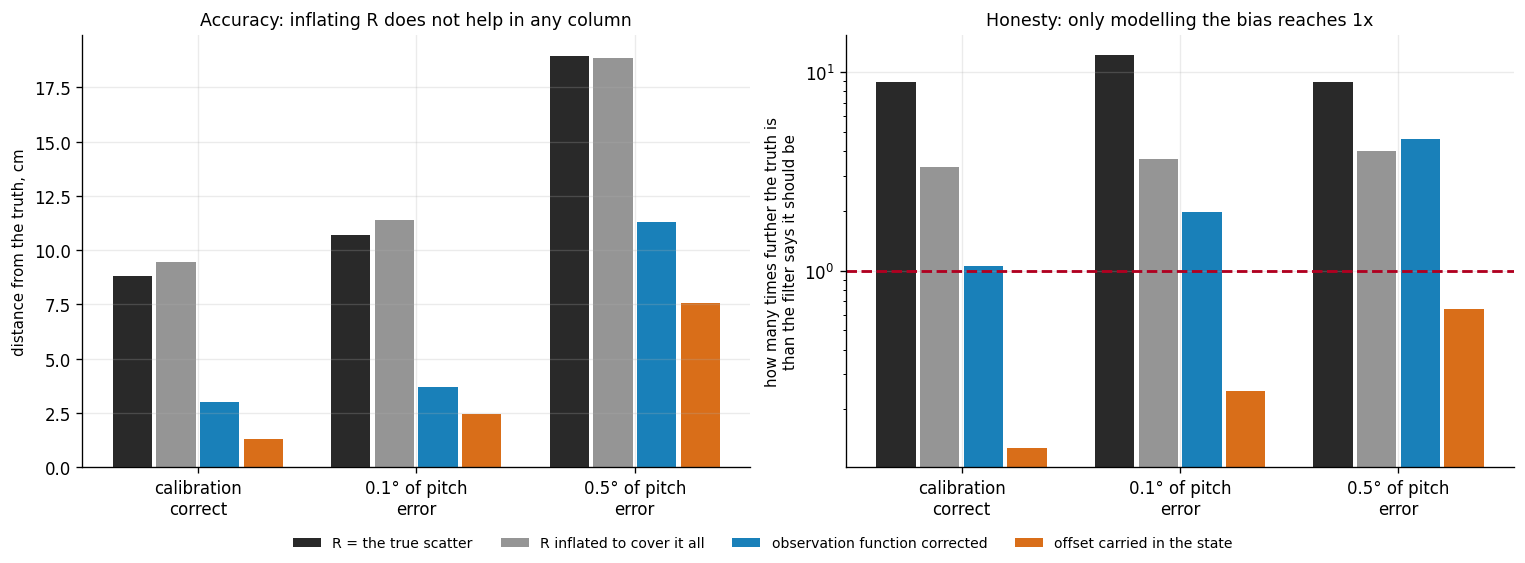

In [5]:
nv.calibration_arms(table)

### The three things to take from that table

**1. Inflating $\mathbf{R}$ never improves accuracy — in any column.** 8.80 → 9.43 cm
when the calibration is right, 18.96 → 18.85 cm when it is 0.5° out. Widening the
covariance buys an admission of being wrong and nothing else. That is the answer to
"should I raise the noise to cover calibration error": you can, and the robot will still
be in the wrong place, only now it will say so.

**2. Modelling the displacement improves both.** With the calibration right, correcting
the observation function takes the belief from 8.9× too sure to **1.1× — honest** — and
the error from 8.80 to 3.02 cm.

**3. A calibration error is the same kind of object.** It is repeatable and
pose-dependent, so it is a bias field, not noise; the correction and the offset state
both degrade gracefully into it rather than breaking. The offset state does best because
it estimates what it cannot predict, and it needs no ground truth to do so.

## Why a calibration error is a bias and not noise

Worth making concrete, because it is the crux of the answer above.

In [6]:
sensitivity = nm.calibration_sensitivity(
    models, LEAD,
    [("pitch off by 0.1 deg", dict(dpitch_deg=0.1)),
     ("pitch off by 0.5 deg", dict(dpitch_deg=0.5)),
     ("yaw off by 0.5 deg", dict(dyaw_deg=0.5)),
     ("mounted 2 cm too high", dict(dz=0.02)),
     ("mounted 5 cm too high", dict(dz=0.05))],
    [(1.075, -4.4), (1.075, 0.0), (1.075, 4.0)])

nv.report_calibration_sensitivity(sensitivity)

  this camera is 640 px per radian, so 0.64 px per milliradian:

  calibration error           1.5 m away    5.6 m away    9.6 m away
  pitch off by 0.1 deg            0.9 cm        1.9 cm        4.1 cm
  pitch off by 0.5 deg            4.4 cm        9.7 cm       20.3 cm
  yaw off by 0.5 deg              1.3 cm        4.9 cm        8.3 cm
  mounted 2 cm too high           0.6 cm        2.3 cm        4.0 cm
  mounted 5 cm too high           1.6 cm        5.8 cm       10.0 cm

  Every row grows with range, which is the signature of a BIAS FIELD and not
  of noise: the same displacement every time the robot stands in the same place.


A tenth of a degree of pointing error is 1.1 px — already larger than this camera's
entire measured detector noise — and 4.1 cm of floor at the far end of the aisle. Half a
degree is 20 cm.

But every row **grows with range**, smoothly, and repeats exactly whenever the robot
returns to the same place. That is a bias field. Putting it into $\mathbf{R}$ would be
the same category error as putting the silhouette lean there, and it fails the same way:
the belief becomes confidently wrong instead of honestly uncertain.

**Which also settles what these captures can and cannot say.** The projection here is
parsed from the world file Gazebo renders from and the camera model carries no distortion
term, so the calibration error in the recorded data is *identically zero*. The 0.4 to
0.8 px measured in notebook 5 is pure detector variability with no calibration
contribution. On real hardware calibration would be the leading term — which is an
argument for modelling it, not for widening a covariance to hide it.

## One consequence that has to be said out loud

Correcting the observation function makes the innovations small. A $\chi^2$ gate whose
threshold was chosen when they were large then starts rejecting perfectly good readings,
and each rejection lets the belief drift, which makes the next innovation larger.

In [7]:
oracle = nm.oracle_noise(seq, LEAD)
nv.report_gate_after_correction(nm.gate_after_correction(
    seq, models, LEAD, {LEAD: oracle["R_spread"][LEAD]}, {LEAD: oracle["R_total"][LEAD]},
    nm.heading_from_odometry(seq)))

  gate on, as deployed  kept 136 of 276 readings     2.2x too sure   RMSE  11.68 cm
  gate off              kept 276 of 276 readings     1.1x too sure   RMSE   3.02 cm

  Once the observation function is right the innovations are small, and a
  threshold chosen when they were large starts rejecting good readings. Each
  rejection lets the belief drift, which makes the next innovation larger,
  which rejects more. The gate has to be re-derived with the model, not kept.


Half the readings thrown away, and the error four times worse than with the gate off.
**The gate is not an independent safety device: it is part of the observation model, and
it has to be re-derived whenever that model changes.** Keeping a threshold tuned against
a biased observation function is how a genuine improvement turns into a regression.

## Conclusion

**What to defend.** The camera's error is about 90% a repeatable, pose-dependent
displacement. It is predictable from the robot's own geometry with zero fitted
parameters, using odometry heading and no ground truth, and it transfers across four
routes with a control that fails as it should. Correcting the observation function makes
the belief honest (1.1×) where no covariance could. What is left over is small, and
*its* shape and orientation are the projection's, with one scalar left to estimate —
notebook 5.

**What that says about the blend.** `plan_covariance` interpolates a scalar trust
between two asserted covariances. It was being asked to represent a bias field with a
variance, and no choice of endpoints, exponent or trust can do that. The fix is not a
better blend but a different decomposition:

| quantity | what sets it | needs data? |
|---|---|---|
| does a reading arrive at all | occlusion, detector, lighting | **yes — this is the GP's job** |
| where it will land | robot geometry and viewing angle | **no — zero parameters** |
| how noisy it is when it does | the projection's derivative × one scalar | shape no, scale one number |
| how much of that is actually known here | the drives | yes — and say so, notebook 5 |

**Limits, stated rather than waited for.** One camera, one world, simulation. The
cross-aisle drive only reaches 3.19 cm because the predictor assumes an unoccluded
silhouette. The residual scale still varies about 57% across range and is not fully
explained. And the calibration section is an ablation on a perturbed model, not a
hardware measurement — it shows what a calibration error *does*, not what this rig's
calibration *is*.

---

*Four recorded Gazebo drives in the AWS warehouse, no synthetic data. The calibration
section perturbs the camera MODEL and leaves the recorded pixels untouched; it is
labelled a controlled ablation wherever it appears. Every estimator is shared through
`notebook_model.py` and every figure through `notebook_views.py`.*